<a href="https://colab.research.google.com/github/dnhshl/cc-ai/blob/main/cv_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 3: Computer Vision (YOLO & SAM)
### KI in der Robotik - Hochschule Hamm-Lippstadt

In diesem Modul zeigen wir, wie der Roboter seinen Zustand $s$ direkt aus Kamerabildern ableiten kann.
Anstatt komplexer Bildverarbeitungsalgorithmen nutzen wir modernste **Deep Learning Modelle**, die in Echtzeit Objekte erkennen und segmentieren können.

Wir vergleichen zwei Ansätze:
1.  **YOLO (You Only Look Once):** Liefert Bounding Boxes (Rechtecke) für die Hindernisvermeidung.
2.  **SAM (Segment Anything Model):** Liefert pixelgenaue Masken für präzises Greifen (Grasping).

In [1]:
# 1. Installation & Setup
!pip install ultralytics

from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

# Wir laden ein Testbild, das eine typische Robotik-Szene darstellt
img_url = 'https://ultralytics.com/images/bus.jpg'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. YOLO: Bounding Box Detection (Folie 49)
YOLO ist der Standard für Echtzeit-Objekterkennung in der Robotik. Es teilt das Bild in ein Gitter und sagt für jede Zelle vorher, ob und wo sich ein Objekt befindet. Dies geschieht in einem einzigen Durchlauf des neuronalen Netzes.

**Anwendung:** Hindernisvermeidung, Objektlokalisierung.


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 784.6ms
Speed: 28.7ms preprocess, 784.6ms inference, 55.0ms postprocess per image at shape (1, 3, 640, 480)


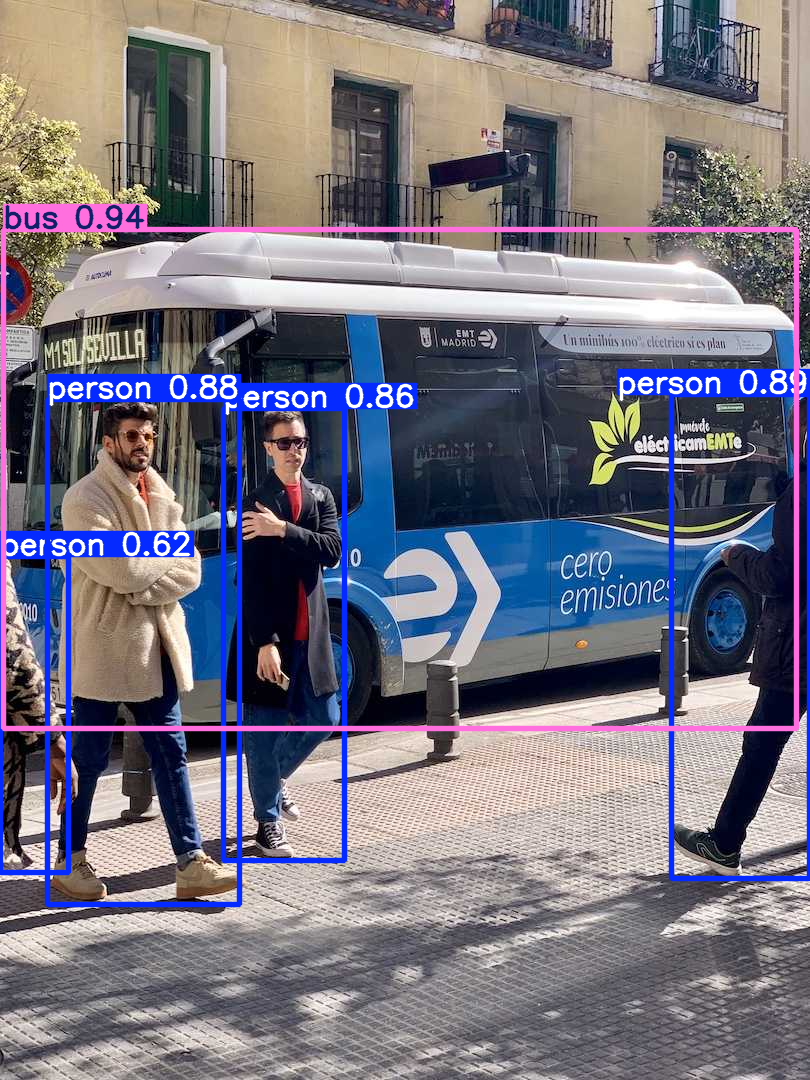

In [2]:
# Lade ein vortrainiertes YOLO-Modell (Nano-Größe für Speed)
model_yolo = YOLO('yolo11n.pt')

# Führe die Objekterkennung durch
results_yolo = model_yolo.predict(img_url, conf=0.5) # Konfidenz-Schwelle 50%

# Visualisiere das Ergebnis
for r in results_yolo:
    # Zeichne Bounding Boxes und Labels ins Bild
    res_plotted = r.plot()
    cv2_imshow(res_plotted)

### Didaktischer Hinweis (YOLO)
Sie können hier den Bezug zur **Pose Estimation (Folie 49)** herstellen. Aus der Größe und Position der Bounding Box im 2D-Bild kann der Roboter (mit Kalibrierung) auf die 3D-Position im Raum schließen.



## 3. SAM: Instance Segmentation (Folie 50)
Für das **Greifen (Grasping)** ist eine Bounding Box oft nicht genau genug. Der Roboter muss wissen, wo die exakten Kanten des Objekts sind, um seine Finger korrekt zu platzieren.
Das **Segment Anything Model (SAM)** liefert für jedes erkannte Objekt eine pixelgenaue Maske.

**Anwendung:** Präzises Greifen, Qualitätskontrolle.


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 3 persons, 1 bus, 357.1ms
Speed: 4.6ms preprocess, 357.1ms inference, 9.5ms postprocess per image at shape (1, 3, 640, 480)


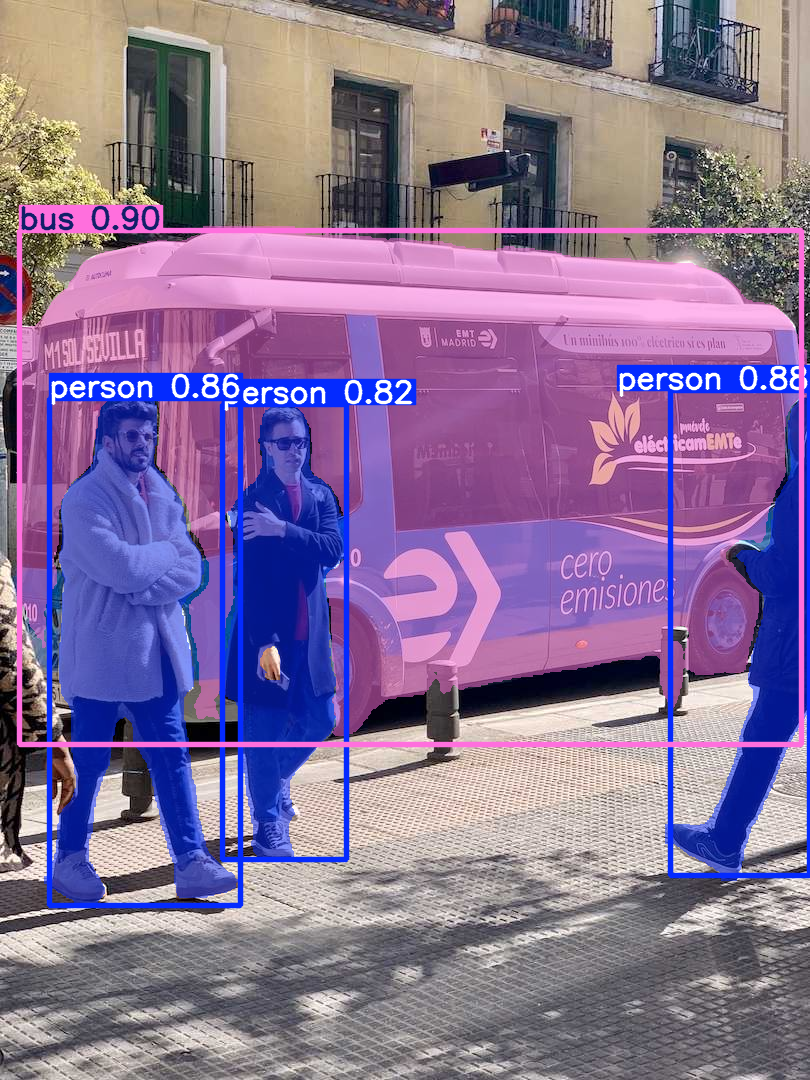

In [3]:
# Lade das SAM-Modell für Segmentation
model_sam = YOLO('yolo11n-seg.pt') # 'seg' steht für Segmentation

# Führe die Segmentation durch
results_sam = model_sam.predict(img_url, conf=0.5)

# Visualisiere das Ergebnis
for r in results_sam:
    # Zeichne die farbigen Segmentierungsmasken
    seg_plotted = r.plot()
    cv2_imshow(seg_plotted)

### Didaktischer Hinweis (SAM)
Zeigen Sie den Unterschied zwischen den Rechtecken von YOLO und den präzisen Masken von SAM. Dies verdeutlicht den Unterschied zwischen **Detektion** (Wo ist es grob?) und **Segmentierung** (Wo ist es genau?).
Erklären Sie, dass diese Maske der Input für den Algorithmus wäre, der den optimalen Greifpunkt (Grasp Pose) berechnet.



## 4. Brücke zum Reinforcement Learning
Wie passt das zu unserem **DQN-Agenten (Modul 2)**?
Anstatt dem neuronalen Netz das rohe Kamerabild zu geben (was sehr viele Daten sind), können wir die Ausgabe von YOLO als **Zustand $s$** nutzen.

**Beispiel für den State-Vektor $s$:**
`s = [Klasse_1, x1, y1, w1, h1, Klasse_2, x2, y2, w2, h2]`

Das macht das Lernen viel effizienter, da das Wahrnehmungsproblem bereits vom Vision-Modell gelöst wurde.